<a href="https://colab.research.google.com/github/JCSR2022/Alura_Data_Science/blob/main/Flight_Delay_Prediction_Project/Optimizacion_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Project

We will be developing a Machine Learning model using Scikit-learn, with flight delay data from an airport contained in the file 'flights.csv'.

The goal of this project is to generate a model that allows us to accurately predict flight delays, thereby optimizing airport operations.

# 0.1 Libs

In [13]:
# -----------------------------
# Librerias
# -----------------------------

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import yellowbrick

In [39]:
# -----------------------------
# Configuración visual global
# -----------------------------
PALETTE = sns.color_palette("Blues", as_cmap=True)

#style must be one of white, dark, whitegrid, darkgrid, ticks
sns.set_theme(
    style="whitegrid",        # limpio, sin grids pesados
    palette="rocket",         # colores
    font="sans-serif",
    font_scale=1.1
)

In [4]:
#https://github.com/JCSR2022/Alura_Data_Science/blob/main/Flight_Delay_Prediction_Project/flights.csv

git_raw = 'https://raw.githubusercontent.com/'
url_github = 'JCSR2022/Alura_Data_Science/main/Flight_Delay_Prediction_Project/flights.csv'
datos = pd.read_csv(git_raw + url_github)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [5]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [6]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


# Exploratory Data Analysis (EDA)

Data Quality: The dataset is robust with 71,175 records and 0 null values, facilitating the direct start of modeling.

Delay Behavior: * 25% of flights are not delayed, but rather depart early (up to -4.41 min).

The median (50%) is ~9.74 minutes, but the average is higher (12.5 min), indicating a distribution skewed by flights with critical delays.

There is an extreme maximum value of 125 minutes, which represents the main challenge for operational optimization.

Volatility: The standard deviation is 23 minutes, indicating high variability that justifies the use of advanced models such as Random Forest Regressor.

## Airline delays

In [22]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()

,airline,delay
1,MM,40.50
2,YE,25.77
0,BZ,3.08


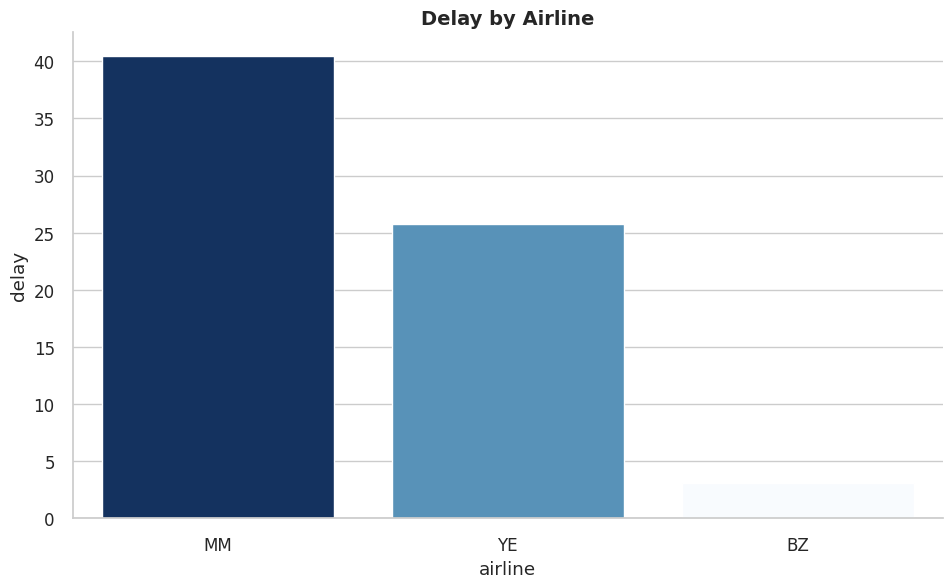

In [40]:
def show_table(df,sorted_by=None):
    if sorted_by:
        df = df.sort_values(by=sorted_by,ascending=False)
    return (
        df.style
        .background_gradient(cmap=PALETTE)
        .format(precision=2)
        .set_properties(**{
            "text-align": "center"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("font-weight", "bold"),
                 ("text-align", "center")
             ]}
        ])
    )

def barplot(df, x, y, title):

    df = df.sort_values(by=y, ascending=False)

    fig, ax = plt.subplots(figsize=(10,6))

    sns.barplot(
        data=df,
        x=x,
        y=y,
        hue=y,                 # permite mapear intensidad del color
        palette=PALETTE,       # más alto = más oscuro
        legend=False,
        ax=ax
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    sns.despine()

    return fig

display(show_table(avg_delay,'delay'))
print()
barplot(avg_delay, 'airline', 'delay', 'Delay by Airline').show()

,airline,delay
1,MM,40.50
2,YE,25.77
0,BZ,3.08


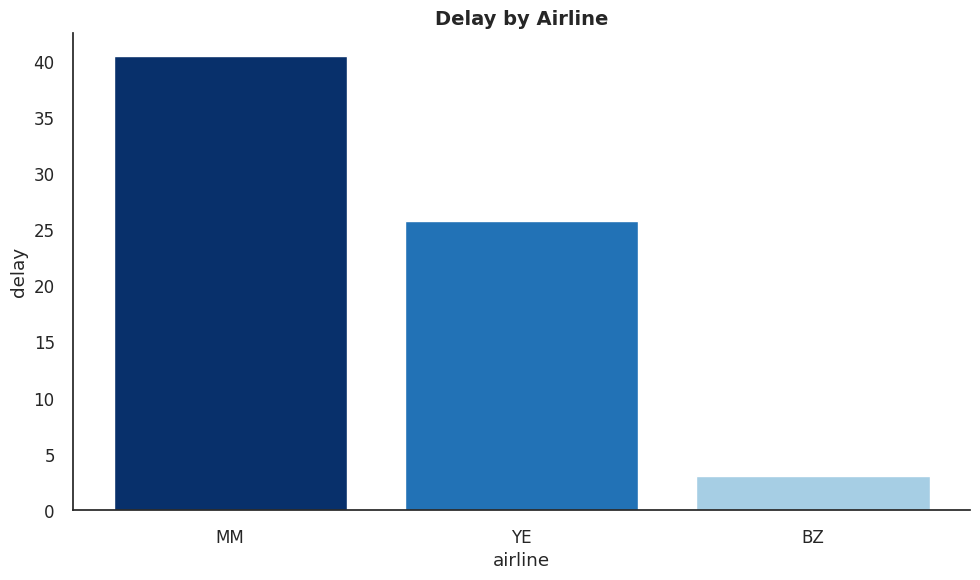

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# -----------------------------
# Configuración visual global
# -----------------------------
sns.set_theme(style="white", font_scale=1.1)

CMAP = sns.color_palette("Blues", as_cmap=True)

# rango visible del colormap (evita los tonos demasiado claros)
COLOR_MIN = 0.35
COLOR_MAX = 1.0


# -----------------------------
# Tabla estilizada
# -----------------------------
def show_table(df, column):
    if column:
        df = df.sort_values(by=column,ascending=False)

    vmin = df[column].min()
    vmax = df[column].max()

    return (
        df.style
        .background_gradient(
            cmap=CMAP,
            subset=[column],
            vmin=vmin,
            vmax=vmax
        )
        .format(precision=2)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th",
             "props": [("font-weight", "bold"),
                       ("text-align", "center")]}
        ])
    )


# -----------------------------
# Barplot estandarizado
# -----------------------------
def barplot(df, x, y, title):

    df = df.sort_values(by=y, ascending=False)

    norm = Normalize(df[y].min(), df[y].max())

    colors = [
        CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))
        for v in df[y]
    ]

    fig, ax = plt.subplots(figsize=(10,6))

    ax.bar(df[x], df[y], color=colors)

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    sns.despine()
    plt.tight_layout()

    return fig

avg_delay = datos.groupby('airline')['delay'].mean().reset_index()

display(show_table(avg_delay, 'delay'))

barplot(avg_delay, 'airline', 'delay', 'Delay by Airline').show()